In [1]:
!wget https://bioconnector.github.io/workshops/data/airway_scaledcounts.csv
!wget https://bioconnector.github.io/workshops/data/airway_metadata.csv

--2026-02-02 08:08:46--  https://bioconnector.github.io/workshops/data/airway_scaledcounts.csv
Resolving bioconnector.github.io (bioconnector.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to bioconnector.github.io (bioconnector.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2102792 (2.0M) [text/csv]
Saving to: ‘airway_scaledcounts.csv’

airway_scaledcounts 100%[===================>]   2.00M  --.-KB/s    in 0.06s   

2026-02-02 08:08:47 (34.4 MB/s) - ‘airway_scaledcounts.csv’ saved [2102792/2102792]

--2026-02-02 08:08:47--  https://bioconnector.github.io/workshops/data/airway_metadata.csv
Resolving bioconnector.github.io (bioconnector.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to bioconnector.github.io (bioconnector.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 325 [text/csv]
Saving to: ‘airway_metadata.csv’


In [2]:
import pandas as pd
expr_df = pd.read_csv("airway_scaledcounts.csv")
expr_df = expr_df.set_index(["ensgene"])
expr_df
#유전자별로 gene이 얼마나 많이 카운트 되었는지

,SRR1039508,SRR1039509,SRR1039512,SRR1039513,SRR1039516,SRR1039517,SRR1039520,SRR1039521
ensgene,,,,,,,,
ENSG00000000003,723.0,486.0,904.0,445.0,1170.0,1097.0,806.0,604.0
ENSG00000000005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000000419,467.0,523.0,616.0,371.0,582.0,781.0,417.0,509.0
ENSG00000000457,347.0,258.0,364.0,237.0,318.0,447.0,330.0,324.0
ENSG00000000460,96.0,81.0,73.0,66.0,118.0,94.0,102.0,74.0
...,...,...,...,...,...,...,...,...
ENSG00000283115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000283116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000283119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
meta_df = pd.read_csv("airway_metadata.csv")
meta_df

,id,dex,celltype,geo_id
0,SRR1039508,control,N61311,GSM1275862
1,SRR1039509,treated,N61311,GSM1275863
2,SRR1039512,control,N052611,GSM1275866
3,SRR1039513,treated,N052611,GSM1275867
4,SRR1039516,control,N080611,GSM1275870
5,SRR1039517,treated,N080611,GSM1275871
6,SRR1039520,control,N061011,GSM1275874
7,SRR1039521,treated,N061011,GSM1275875


In [4]:
# 데이터 전처리: 그룹 지정
group1 = meta_df[meta_df['dex'] == 'control']['id']
group2 = meta_df[meta_df['dex'] == 'treated']['id']

In [5]:
group1

,id
0,SRR1039508
2,SRR1039512
4,SRR1039516
6,SRR1039520


In [6]:
group2

,id
1,SRR1039509
3,SRR1039513
5,SRR1039517
7,SRR1039521


In [8]:
#Rstudio-->EdgeR, limma 패키지
#3~4줄로 DEG 도출 가능

In [7]:
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

# 유의미한 DEG 찾기
p_values = []
for gene in expr_df.index:
    group1_values = expr_df.loc[gene, group1].astype(float)
    group2_values = expr_df.loc[gene, group2].astype(float)
    p_value = stats.ttest_ind(group1_values, group2_values, equal_var=True)[1]
    p_values.append(p_value)
#group1과 group2를 가지고와서 t-test 진행

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment 

In [9]:
# Bonferroni 보정: 각 p-value를 비교한 테스트 수로 곱하여 보정
p_adjusted = np.array(p_values) * len(expr_df.index)
p_adjusted = np.minimum(p_adjusted, 1.0)

# 결과 정리
results = pd.DataFrame({'gene': expr_df.index, 'p_value': p_values, 'p_adjusted': p_adjusted})
deg_genes = results[results['p_adjusted'] < 0.05]

deg_genes

,gene,p_value,p_adjusted
3620,ENSG00000109061,0.0,0.0
7800,ENSG00000139330,0.0,0.0
10919,ENSG00000163206,0.0,0.0
19066,ENSG00000213315,0.0,0.0
26530,ENSG00000236108,0.0,0.0
31087,ENSG00000255058,0.0,0.0
32095,ENSG00000258806,0.0,0.0
33725,ENSG00000267741,0.0,0.0


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


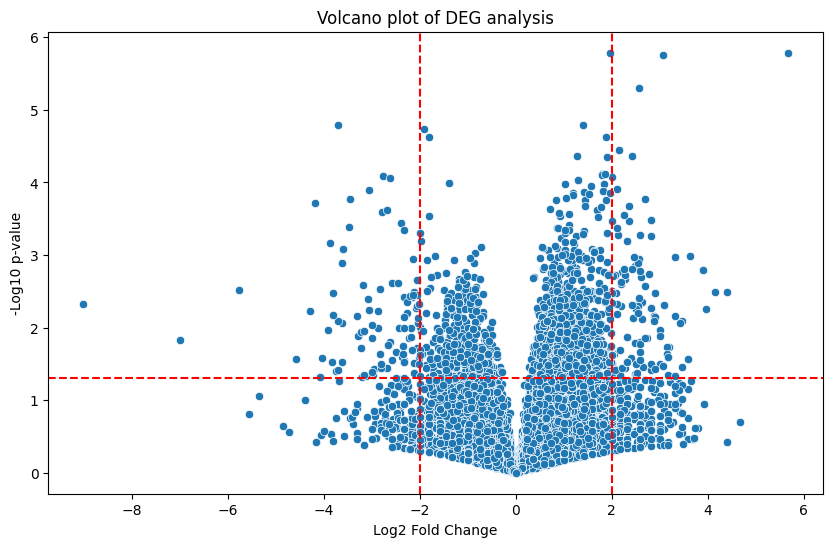

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

results['log_p_value'] = -np.log10(results['p_value'])
results['log_fold_change'] = np.log2(data[group1].mean(axis=1) / data[group2].mean(axis=1))

plt.figure(figsize=(10, 6))
sns.scatterplot(x='log_fold_change', y='log_p_value', data=results)
plt.axhline(y=-np.log10(0.05), color='r', linestyle='--')
plt.axvline(x=-2, color='r', linestyle='--')
plt.axvline(x=2, color='r', linestyle='--')
plt.xlabel('Log2 Fold Change')
plt.ylabel('-Log10 p-value')
plt.title('Volcano plot of DEG analysis')
plt.show()